## 0. Imports & Configuration

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Style global
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11
sns.set_palette('husl')

AIRPORTS = ['Ajaccio', 'Bastia', 'Bron', 'Nantes', 'Biarritz', 'Pise']
AIRPORT_COORDS = {
    'Bron':    (4.9389,  45.7294),
    'Bastia':  (9.4837,  42.5527),
    'Ajaccio': (8.8029,  41.9236),
    'Nantes':  (-1.6107, 47.1532),
    'Pise':    (10.399,  43.695),
    'Biarritz':(-1.524,  43.4683),
}
print('✅ Imports OK')

✅ Imports OK


In [4]:
path = '../data/segment_alerts_all_airports_train.csv'
df = pd.read_csv(path)
print(f'Shape : {df.shape}')
IDS = ['lightning_id','lightning_airport_id','date','lon','lat','airport','airport_alert_id']
df.head()

Shape : (507071, 13)


,lightning_id,lightning_airport_id,date,lon,lat,amplitude,maxis,icloud,dist,azimuth,airport,airport_alert_id,is_last_lightning_cloud_ground
0,1,1,2016-01-02 14:53:36+00:00,9.0559,42.0826,-9.90,0.3,False,27.360653,57.852343,Ajaccio,NaN,NaN
1,2,2,2016-01-02 14:53:36+00:00,9.0236,42.0953,-3.33,0.2,True,26.383167,52.117828,Ajaccio,NaN,NaN
2,3,3,2016-01-02 21:22:53+00:00,8.8585,42.0456,-18.68,0.4,True,14.313391,24.500543,Ajaccio,NaN,NaN
3,4,4,2016-01-02 21:22:53+00:00,8.8517,42.0517,-7.51,0.2,False,14.794117,20.854458,Ajaccio,1.0,False
4,5,5,2016-01-02 21:24:46+00:00,8.8728,42.0494,-6.01,0.2,False,15.124224,29.058471,Ajaccio,1.0,False


In [5]:
import matplotlib.gridspec as gridspec
def desc_stats(col):
    s = df[col]
    n_total = len(s)
    n_missing = s.isna().sum()
    pct_missing = n_missing / n_total * 100
    
    print(f"=== {col} ===")
    print(f"Manquants     : {n_missing} ({pct_missing:.2f}%)")
    print()
    print(s.describe().to_string())
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle(col, fontsize=13)
    
    # Histogramme + KDE
    s.dropna().plot.hist(ax=axes[0], bins=50, color="steelblue", edgecolor="white")
    axes[0].set_title("Distribution")
    axes[0].set_xlabel(col)
    
    # Boxplot
    s.dropna().plot.box(ax=axes[1], color="steelblue")
    axes[1].set_title("Boxplot")
    
    # Barre missings
    if n_missing > 0:
        for ax in axes:
            ax.set_xlabel(f"{ax.get_xlabel()}\n({pct_missing:.1f}% manquants)")
    
    plt.tight_layout()
    plt.show()


In [6]:
# 2.1 — Types & parsing
VAR = ['dist','azimuth']
df['date'] = pd.to_datetime(df['date'], utc=True)
df['icloud'] = df['icloud'].astype(bool)
df['is_last_lightning_cloud_ground'] = df['is_last_lightning_cloud_ground'].astype('boolean')

# 2.2 — Variables temporelles
df['year']   = df['date'].dt.year
df['month']  = df['date'].dt.month
df['hour']   = df['date'].dt.hour
df['season'] = df['month'].map({
    12:'Hiver', 1:'Hiver', 2:'Hiver',
    3:'Printemps', 4:'Printemps', 5:'Printemps',
    6:'Été', 7:'Été', 8:'Été',
    9:'Automne', 10:'Automne', 11:'Automne'
})
df = df.sort_values(["airport", "date"])
VAR += ['month','hour']
# index reset
df = df.reset_index(drop=True)
# 2.3 — Alerte Pise 2016 (données intra-nuage potentiellement biaisées)
mask_pise_2016 = (df['airport'] == 'Pise') & (df['year'] == 2016) & (df['icloud'] == True)
print(f"⚠️  Éclairs intra-nuage Pise 2016 : {mask_pise_2016.sum()} (à exclure si analyse icloud)")
df_clean = df#.copy()#[~mask_pise_2016]

# 2.4 — Sous-ensembles utiles
df_20km  = df_clean[df_clean['dist'] <= 20].copy()   # zone opérationnelle
df_cg    = df_clean[df_clean['icloud'] == False].copy()  # éclairs nuage-sol uniquement
df_cg_20 = df_cg[df_cg['dist'] <= 20].copy()

print(f"\nDataset nettoyé     : {df_clean.shape[0]:,} éclairs")
print(f"Éclairs ≤ 20 km     : {df_20km.shape[0]:,}")
print(f"Éclairs nuage-sol   : {df_cg.shape[0]:,}")
print(f"CG ≤ 20 km          : {df_cg_20.shape[0]:,}")

⚠️  Éclairs intra-nuage Pise 2016 : 19404 (à exclure si analyse icloud)

Dataset nettoyé     : 507,071 éclairs
Éclairs ≤ 20 km     : 220,498
Éclairs nuage-sol   : 128,992
CG ≤ 20 km          : 56,599


## Temps depuis les derniers éclairs

In [7]:
# temps depuis le dernier éclair (tous types)
df["time_since_last_lightning"] = (
    df.groupby("airport")["date"]
    .diff()
    .dt.total_seconds()
)


# temps depuis le dernier éclair nuage-sol
df["date_cg"] = df["date"].where(df["icloud"] == False)

df["time_since_last_cloud_ground"] = (
    df.groupby("airport")["date_cg"]
    .ffill()
)

df["time_since_last_cloud_ground"] = (
    df["date"] - df["time_since_last_cloud_ground"]
).dt.total_seconds()



# temps depuis le dernier éclair intra-nuage
df["date_ic"] = df["date"].where(df["icloud"] == True)

df["time_since_last_intra_cloud"] = (
    df.groupby("airport")["date_ic"]
    .ffill()
)

df["time_since_last_intra_cloud"] = (
    df["date"] - df["time_since_last_intra_cloud"]
).dt.total_seconds()
###########################################################################
df["time_since_last_lightning"] = df["time_since_last_lightning"].fillna(0)
lightning_mask = df["time_since_last_lightning"]>=3600
df["time_since_last_intra_cloud"] = df["time_since_last_intra_cloud"].fillna(0)
df["time_since_last_cloud_ground"] = df["time_since_last_cloud_ground"].fillna(0)


In [8]:
# Censurer les durées au delà d un seuil, fixé ici à 1h
###########################################################################################
df["time_since_last_cloud_ground2"] = np.log(df["time_since_last_cloud_ground"].clip(0,3600)+1)
df["time_since_last_intra_cloud2"]= np.log(df["time_since_last_intra_cloud"].clip(0,3600).fillna(0)+1)
df["time_since_last_lightning2"] = np.log(df["time_since_last_lightning"].clip(0,3600).fillna(0)+1)
VAR.append("time_since_last_lightning2")
VAR.append("time_since_last_intra_cloud2")
VAR.append("time_since_last_cloud_ground2")


In [9]:
# col = "dist"
# #df[col] = df[col].fillna(0)
# desc_stats(col)

## Nombre d’éclairs récents (fenêtres temporelles)

In [10]:
df = df.set_index("date")

# nombre d'éclairs dans différentes fenêtres
for window in ["1min", "5min", "10min", "20min", "30min"]:
    
    df[f"count_{window}"] =(
        df.groupby("airport")["lightning_id"]
        .rolling(window)
        .count()
        .reset_index(level=0, drop=True)
    )
    df[f"log_count_{window}"] =  np.log(df[f"count_{window}"]+1)
    VAR.append(f"log_count_{window}")

## Comptage par type d’éclair

In [11]:
# éclairs nuage-sol
df["cg"] = (df["icloud"] == False).astype(int)
# éclairs intra-nuage
df["ic"] = (df["icloud"] == True).astype(int)

for window in ["5min", "10min", "20min"]:
    df[f"ic_count_{window}"] = (
        df.groupby("airport")["ic"]
        .rolling(window)
        .sum()
        .reset_index(level=0, drop=True)
    )
    df[f"cg_count_{window}"] = (
        df.groupby("airport")["cg"]
        .rolling(window)
        .sum()
        .reset_index(level=0, drop=True)
    )
    df[f"log_ic_count_{window}"] = np.log(df[f"ic_count_{window}"]+1)
    df[f"log_cg_count_{window}"] = np.log(df[f"cg_count_{window}"]+1)
    VAR+=[f"log_ic_count_{window}", f"log_cg_count_{window}"]

=== log_ic_count_10min ===
Manquants     : 0 (0.00%)

count    507071.000000
mean          4.229013
std           1.640422
min           0.000000
25%           3.218876
50%           4.543295
75%           5.521461
max           7.331060


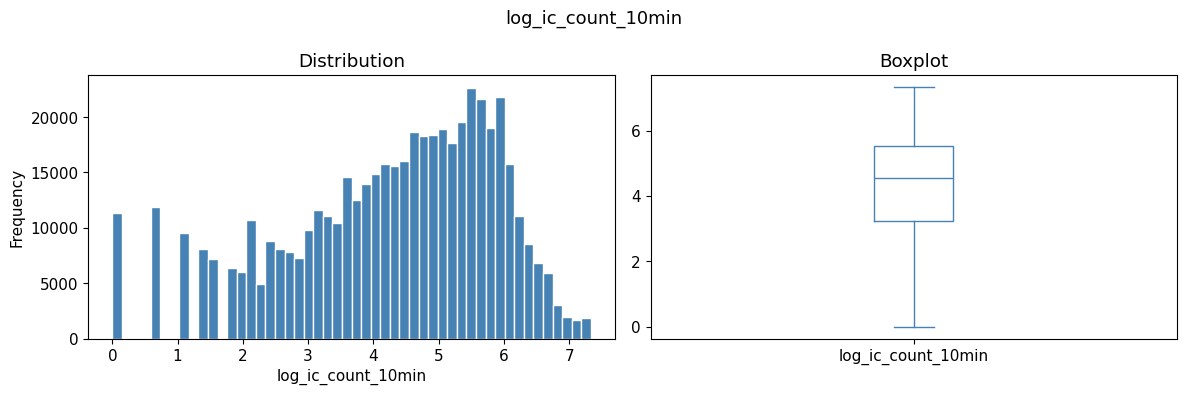

In [12]:
col = "log_ic_count_10min"
#df[col] = df[col].fillna(0)
desc_stats(col)

## Taux d'activité

In [13]:
df["rate_1min"] = df["count_1min"]
df["rate_5min"] = df["count_5min"] / 5
df["rate_10min"] = df["count_10min"] / 10

df["rate_trend"] = np.log(df["count_10min"] - df["count_5min"]+1)

df["activity_decay"] = df["rate_5min"] / (df["rate_10min"] + 1e-6)

VAR+=["rate_trend","activity_decay"]

## Variable spatiale

In [14]:
for window in ["1min", "5min", "10min"]:
    
    df[f"mean_dist_{window}"] = (
        df.groupby("airport")["dist"]
        .rolling(window)
        .mean()
        .reset_index(level=0, drop=True)
    )
    
    df[f"min_dist_{window}"] = (
        df.groupby("airport")["dist"]
        .rolling(window)
        .min()
        .reset_index(level=0, drop=True)
    )
    VAR+=[f"mean_dist_{window}",f"min_dist_{window}"] 

df["distance_trend"] = df["mean_dist_1min"] - df["mean_dist_10min"]
#dispersion spatiale

df["std_lat_10min"] = (
    df.groupby("airport")["lat"]
    .rolling("10min")
    .std()
    .reset_index(level=0, drop=True)
)

df["std_lon_10min"] = (
    df.groupby("airport")["lon"]
    .rolling("10min")
    .std()
    .reset_index(level=0, drop=True)
)

VAR+=["distance_trend","std_lat_10min","std_lon_10min","azimuth_change"]
#direction du front orageux
# les NA dans std_azimuth_ sont dus à une absence de valeurs dans la fenetre emporelle
# l imputation par 0 prends tout son sens
###################################################################
df["std_lon_10min"] = df["std_lon_10min"].fillna(0)
df["std_lat_10min"] = df["std_lat_10min"].fillna(0)
for window in ["1min", "10min"]:
    df[f"mean_azimuth_{window}"] = (
        df.groupby("airport")["azimuth"]
        .rolling(window)
        .mean()
        .reset_index(level=0, drop=True)
    )

    df[f"std_azimuth_{window}"] = (
        df.groupby("airport")["azimuth"]
        .rolling(window)
        .std()
        .reset_index(level=0, drop=True)
    )
    df[f"std_azimuth_{window}"] = df[f"std_azimuth_{window}"].fillna(0)
    VAR+=[f"mean_azimuth_{window}",f"std_azimuth_{window}"]

df["azimuth_change"] = df["mean_azimuth_1min"] - df["mean_azimuth_10min"]

=== azimuth_change ===
Manquants     : 0 (0.00%)

count    507071.000000
mean         -3.363007
std          28.811422
min        -314.727072
25%         -11.150848
50%          -1.535720
75%           5.863439
max         308.090097


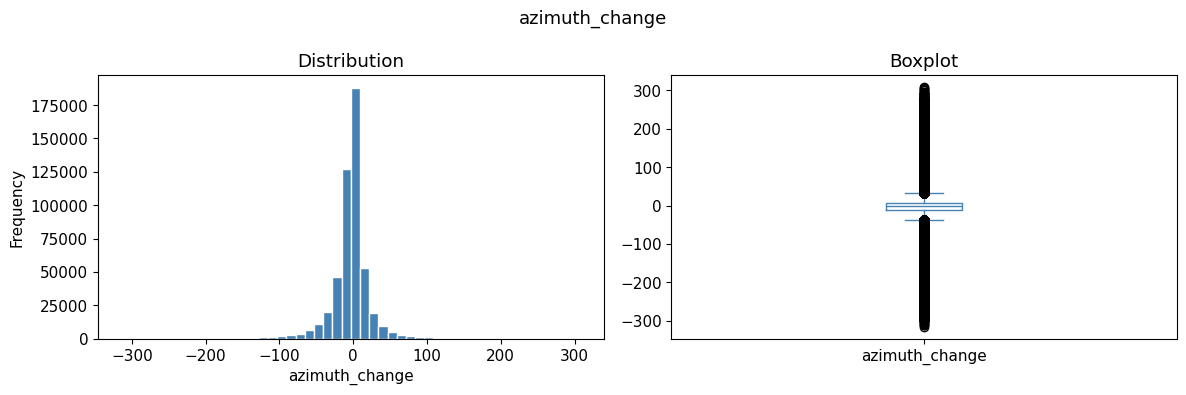

In [15]:
col = "azimuth_change"
desc_stats(col)

## intensité électrique

In [16]:
for window in ["1min", "10min"]:
    df[f"mean_amplitude_{window}"] = (
        df.groupby("airport")["amplitude"]
        .rolling(window)
        .mean()
        .reset_index(level=0, drop=True)
    )

    df[f"max_amplitude_{window}"] = (
        df.groupby("airport")["amplitude"]
        .rolling(window)
        .max()
        .reset_index(level=0, drop=True)
    )
    VAR+=[f"mean_amplitude_{window}",f"max_amplitude_{window}"]

df["amplitude_change"] = df["mean_amplitude_1min"] - df["mean_amplitude_10min"]

df["std_amplitude_10min"] = (
    df.groupby("airport")["amplitude"]
    .rolling("10min")
    .std()
    .reset_index(level=0, drop=True)
)
###################################################################
df["log_std_amplitude_10min"] = np.log(df["std_amplitude_10min"].fillna(0)+1)
VAR+=["amplitude_change","log_std_amplitude_10min"]

## Durée d alerte

In [17]:
#ratio nuage-sol
df["cg_ratio"] = df["cg_count_10min"] / (df["count_10min"] + 1e-6)
#burst d’éclairs
df["burst_indicator"] = (df["count_1min"] > 5).astype(int)
df["date"] = pd.to_datetime(df.index, utc=True)
#durée d'alerte
df["alert_start"] = (
    df.groupby(["airport", "airport_alert_id"])["date"]
    .transform("min")
)


df["alert_duration"] = (
    df.index - df["alert_start"]
).dt.total_seconds()
#########################################################
df["alert_duration"] = df["alert_duration"].fillna(0).clip(0,3600)
#df = df.reset_index()
VAR+= ["cg_ratio","burst_indicator","alert_duration"]

## Vitesse de déplacement de l’orage

In [18]:
# différence temporelle entre éclairs
df["delta_t"] = (
    df.groupby("airport")["date"]
    .diff()
    .dt.total_seconds()
)

# déplacement spatial approximatif
df["delta_dist"] = df.groupby("airport")["dist"].diff()

# vitesse radiale (km/sec)
df["storm_velocity"] = df["delta_dist"] / (df["delta_t"] + 1e-6)

VAR+=["delta_dist","storm_velocity"]
# par soucis de coherence, pour des éclairs avec plus d une heure d écart, la variation de distance passera à 0
bol = df["time_since_last_lightning"]>=3600
df.loc[bol,["delta_dist","storm_velocity"]] = 0
df.loc[:,["delta_dist","storm_velocity"]] = df.loc[:,["delta_dist","storm_velocity"]].fillna(0)

## Accélération de l’activité électrique

In [19]:
# variation du taux d'activité
df["activity_acceleration"] = (
    df["rate_1min"] - df["rate_5min"]
)
# df["activity_trend"] = (
#     df["count_10min"]- df["count_5min"]
# )
VAR+=["activity_acceleration"]

=== activity_acceleration ===
Manquants     : 0 (0.00%)

count    507071.000000
mean          0.963427
std           5.275369
min         -45.400000
25%          -1.000000
50%           0.800000
75%           2.800000
max          68.800000


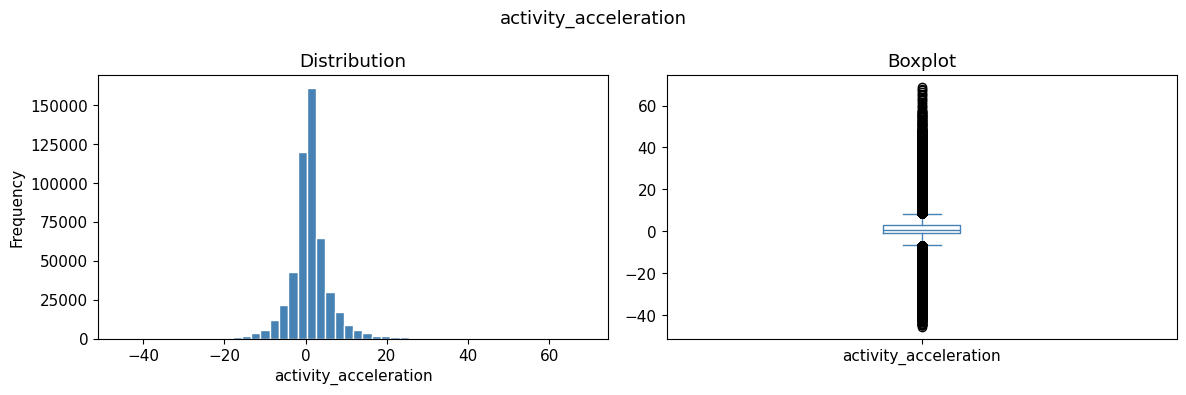

In [20]:
col = "activity_acceleration"
#df[col] = df[col].fillna(0)
desc_stats(col)

## Silence time

In [21]:
# indicateurs de silence prolongé
df["silence_30min"] = (df["time_since_last_lightning"] > 1800).astype(int)
VAR+=["silence_30min"]


## direction du déplacement

In [22]:
df["azimuth_diff"] = df.groupby("airport")["azimuth"].diff()
######################################################
df["azimuth_diff"] = df["azimuth_diff"].fillna(0)
lightning_mask = df['time_since_last_lightning']>=3600
df.loc[lightning_mask,'azimuth_diff'] = 0
df["storm_direction_change"] = np.log(df["azimuth_diff"].abs()+1)
VAR+=["azimuth_diff","storm_direction_change"]

## Distance du centre de l’orage à l’aéroport

In [23]:
# centre de masse des éclairs dans les 10 dernières minutes

df["storm_lat_center"] = (
    df.groupby("airport")["lat"]
    .rolling("10min")
    .mean()
    .reset_index(level=0, drop=True)
)

df["storm_lon_center"] = (
    df.groupby("airport")["lon"]
    .rolling("10min")
    .mean()
    .reset_index(level=0, drop=True)
)

# récupérer coordonnées
df["airport_lat"] = df["airport"].map(lambda x: AIRPORT_COORDS[x][0])
df["airport_lon"] = df["airport"].map(lambda x: AIRPORT_COORDS[x][1])

# distance euclidienne simple (approximation locale)

df["storm_center_distance"] = np.sqrt(
    (df["storm_lat_center"] - df["airport_lat"])**2 +
    (df["storm_lon_center"] - df["airport_lon"])**2
)

# déplacement du centre
df["storm_center_move"] = (
    df.groupby("airport")["storm_center_distance"]
    .diff()
)
#########################################
df["storm_center_move"] = df["storm_center_move"].fillna(0)
df.loc[lightning_mask,"storm_center_move"] = 0
# vitesse (distance / temps)

df["storm_center_velocity"] = (
    df["storm_center_move"] /(
    df["time_since_last_lightning"] + 1)
)
df["storm_spread"] = (
    df["std_lat_10min"] + df["std_lon_10min"]
)
VAR+=["storm_center_velocity","storm_spread","storm_center_distance","storm_center_move"]

# Création de la target : temps jusqu’au prochain éclair

In [24]:
# éclair nuage-sol
df["is_cloud_ground"] = 1*(df["icloud"] == False)

# 1️⃣ identifier les éclairs cloud-ground dans 20 km
df["cg_20km"] = (
    (~df["icloud"]) &
    (df["dist"] <= 20)
)

# 2️⃣ créer une colonne avec date seulement pour ces événements
df["cg20_date"] = df["date"].where(df["cg_20km"])

# 3️⃣ prochain événement dans chaque aéroport
df["next_cg20_date"] = (
    df.groupby("airport")["cg20_date"]
    .bfill()
)

# 4️⃣ temps jusqu'au prochain éclair
df["time_to_next_cg20"] = (
    df["next_cg20_date"] - df["date"]
).dt.total_seconds()

df["time_to_next_cg20"]  = df["time_to_next_cg20"].clip(0,3600)
# 5️⃣ supprimer les lignes sans événement futur
df = df[df["time_to_next_cg20"].notna()]


VAR+=["is_cloud_ground","cg_20km"]
TARGET = ["time_to_next_cg20"]


In [25]:
# Transformation logarithmique
df["target_log_time"] = np.log(df["time_to_next_cg20"]+1)# np.log1p(df["time_to_next_cg20"])# pred_time = np.expm1(pred_log)

# Transformation par classes temporelles
bins = [0, 300, 600, 1200, 1800, np.inf] # en secondes

labels = [0,1,2,3,4]

df["target_bins"] = pd.cut(
    df["time_to_next_cg20"],
    bins=bins,
    labels=labels,
    include_lowest=True
)
TARGET+=["target_log_time","target_bins"]

=== target_log_time ===
Manquants     : 0 (0.00%)

count    507034.000000
mean          3.724461
std           2.463647
min           0.000000
25%           1.945910
50%           3.583519
75%           5.451038
max           8.188967


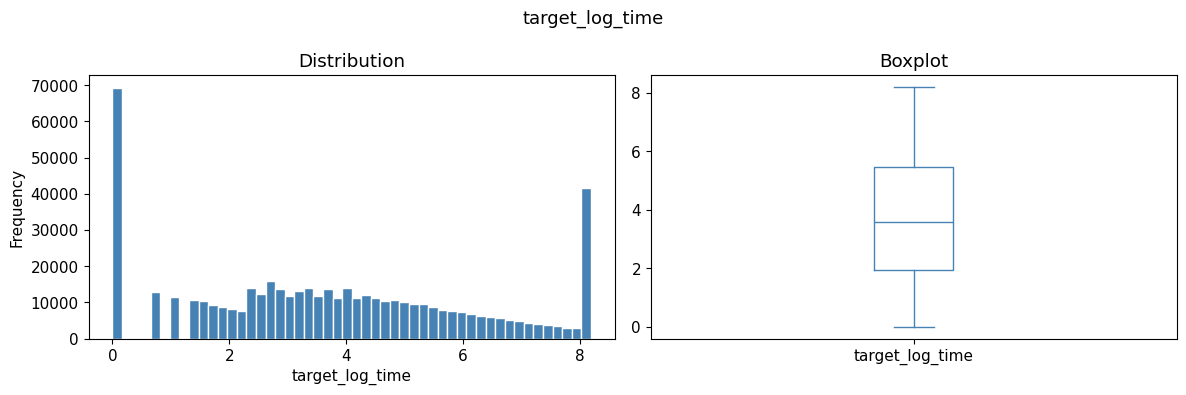

In [26]:
col = "target_log_time"
#df[col] = df[col].fillna(0)
desc_stats(col)

# Split temporel

In [27]:
print(df["date"].min())
print(df["date"].max())

2016-01-02 01:10:41+00:00
2022-12-16 13:17:59+00:00


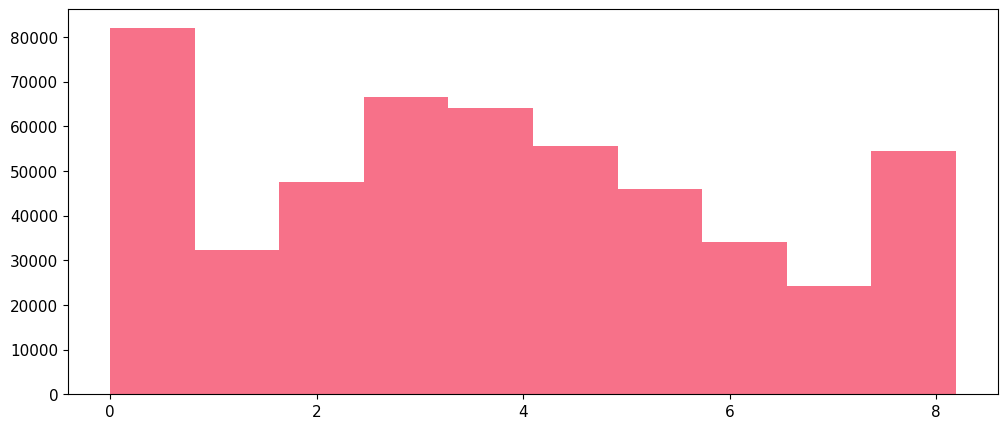

In [28]:
plt.hist(df["target_log_time"])
plt.show()

In [29]:
new = ['season_Automne','season_Hiver','season_Printemps',
        'airport_Ajaccio','airport_Pise','airport_Bastia',
        'airport_Biarritz','airport_Nantes'
        ]
df2 = pd.get_dummies(df)
features = list(set(VAR))
#df2[features] = df2[features].fillna(0)
features += new
df2[new] = df2[new]*1


# train

train = df2[df2["year"] <= 2020]

# validation
val = df2[df2["year"] == 2021]

# test
test = df2[df2["year"] >= 2022]

print("train :",train["date"].min(), train["date"].max())
print("val :",val["date"].min(), val["date"].max())
print("test :",test["date"].min(), test["date"].max())

print(len(features))
X_train = train[features]
y_train = train["target_log_time"]

X_val = val[features]
y_val = val["target_log_time"]

X_test = test[features]
y_test = test["target_log_time"]


train : 2016-01-02 01:10:41+00:00 2020-12-31 23:19:36+00:00
val : 2021-01-01 00:06:55+00:00 2021-12-27 15:12:35+00:00
test : 2022-01-05 13:32:40+00:00 2022-12-16 13:17:59+00:00
63


# Missings?

In [30]:
mis = df2[features].isna().sum()
col_mis = [c for c in mis.index if mis[c]>0]
mis[col_mis]

Series([], dtype: int64)

# Modèles

### Modèle de durée, regression logistique

In [65]:
HORIZON_MIN = 30

df_model = df2.copy()
#
if "index" in df_model.columns and "date" not in df_model.columns:
    df_model = df_model.rename(columns={"index": "date"})

df_model["obs_id"] = np.arange(len(df_model))

# durée en minutes : minimum 1
df_model["duration_min"] = np.maximum(
    1,
    np.ceil(df_model["time_to_next_cg20"] / 60).astype(int)
)

df_model["duration_min_trunc"] = df_model["duration_min"].clip(upper=HORIZON_MIN)
df_model["event_within_horizon"] = (df_model["duration_min"] <= HORIZON_MIN).astype(int)

df_model[["time_to_next_cg20", "duration_min", "duration_min_trunc", "event_within_horizon"]].head()

,time_to_next_cg20,duration_min,duration_min_trunc,event_within_horizon
date,,,,
2016-01-02 14:53:36+00:00,3600.0,60,30,0
2016-01-02 14:53:36+00:00,3600.0,60,30,0
2016-01-02 21:22:53+00:00,0.0,1,1,1
2016-01-02 21:22:53+00:00,0.0,1,1,1
2016-01-02 21:24:46+00:00,0.0,1,1,1


In [66]:
rows = []


id_cols = ["obs_id", "date", "airport", "year"]
target_cols = ["time_to_next_cg20", "duration_min", "duration_min_trunc", "event_within_horizon"]

base_features = features.copy()

for idx, row in df_model.iterrows():
    d = int(row["duration_min_trunc"])
    event_obs = int(row["event_within_horizon"])
    
    for k in range(1, d + 1):
        new_row = {col: row[col] for col in id_cols if col in df_model.columns}
        for col in base_features:
            new_row[col] = row[col]
        
        new_row["spell_id"] = row["obs_id"]
        new_row["t"] = k
        
        # event = 1 seulement à la dernière période si l'événement est observé dans l'horizon
        new_row["event"] = int((k == d) and (event_obs == 1))
        
        rows.append(new_row)

surv_df = pd.DataFrame(rows)
print(surv_df.shape)
surv_df.head()

(2938273, 69)


,obs_id,date,year,mean_dist_5min,month,silence_30min,alert_duration,storm_center_velocity,activity_decay,rate_trend,...,season_Hiver,season_Printemps,airport_Ajaccio,airport_Pise,airport_Bastia,airport_Biarritz,airport_Nantes,spell_id,t,event
0,0,2016-01-02 14:53:36+00:00,2016,27.360653,1,0,0.0,0.0,1.99998,0.0,...,1,0,1,0,0,0,0,0,1,0
1,0,2016-01-02 14:53:36+00:00,2016,27.360653,1,0,0.0,0.0,1.99998,0.0,...,1,0,1,0,0,0,0,0,2,0
2,0,2016-01-02 14:53:36+00:00,2016,27.360653,1,0,0.0,0.0,1.99998,0.0,...,1,0,1,0,0,0,0,0,3,0
3,0,2016-01-02 14:53:36+00:00,2016,27.360653,1,0,0.0,0.0,1.99998,0.0,...,1,0,1,0,0,0,0,0,4,0
4,0,2016-01-02 14:53:36+00:00,2016,27.360653,1,0,0.0,0.0,1.99998,0.0,...,1,0,1,0,0,0,0,0,5,0


In [67]:
surv_df = pd.get_dummies(surv_df, columns=["t"], prefix="t", drop_first=False)

time_cols = [c for c in surv_df.columns if c.startswith("t_")]
print(time_cols[:10], "...", len(time_cols))

['t_1', 't_2', 't_3', 't_4', 't_5', 't_6', 't_7', 't_8', 't_9', 't_10'] ... 30


In [68]:
# train_surv = surv_df[surv_df["year"] <= 2020].copy()
# val_surv   = surv_df[surv_df["year"] == 2021].copy()
# test_surv  = surv_df[surv_df["year"] >= 2022].copy()

# hazard_features = base_features + time_cols
# features_main = [c for c in hazard_features if c not in ["cg_20km"]]

# X_train = train_surv[features_main]
# y_train = train_surv["event"]

# X_val = val_surv[features_main]
# y_val = val_surv["event"]

# X_test = test_surv[features_main]
# y_test = test_surv["event"]

# print(X_train.shape, X_val.shape, X_test.shape)
# print(y_train.mean(), y_val.mean(), y_test.mean())

In [69]:
train_surv = surv_df[surv_df["year"] <= 2020].copy()
val_surv   = surv_df[surv_df["year"] == 2021].copy()
test_surv  = surv_df[surv_df["year"] >= 2022].copy()

hazard_features = base_features + time_cols
features_strict = [c for c in hazard_features if c not in ["cg_20km", "is_cloud_ground"]]

X_train = train_surv[features_strict]
y_train = train_surv["event"]

X_val = val_surv[features_strict]
y_val = val_surv["event"]

X_test = test_surv[features_strict]
y_test = test_surv["event"]

print(X_train.shape, X_val.shape, X_test.shape)
print(y_train.mean(), y_val.mean(), y_test.mean())

(2241404, 91) (223898, 91) (472971, 91)
0.157007839729027 0.15154668643757424 0.1470724420736155


In [70]:
# train_surv = surv_df[surv_df["year"] <= 2020].copy()
# val_surv   = surv_df[surv_df["year"] == 2021].copy()
# test_surv  = surv_df[surv_df["year"] >= 2022].copy()

# hazard_features = base_features + time_cols
# features_C = [c for c in hazard_features if c not in ["cg_20km", "is_cloud_ground", "alert_duration"]]

# X_train = train_surv[features_C]
# y_train = train_surv["event"]

# X_val = val_surv[features_C]
# y_val = val_surv["event"]

# X_test = test_surv[features_C]
# y_test = test_surv["event"]

# print(X_train.shape, X_val.shape, X_test.shape)
# print(y_train.mean(), y_val.mean(), y_test.mean())

In [71]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2241404 entries, 0 to 2737709
Data columns (total 91 columns):
 #   Column                         Dtype  
---  ------                         -----  
 0   mean_dist_5min                 float64
 1   month                          int64  
 2   silence_30min                  int64  
 3   alert_duration                 float64
 4   storm_center_velocity          float64
 5   activity_decay                 float64
 6   rate_trend                     float64
 7   burst_indicator                int64  
 8   amplitude_change               float64
 9   distance_trend                 float64
 10  mean_azimuth_1min              float64
 11  storm_velocity                 float64
 12  time_since_last_cloud_ground2  float64
 13  std_azimuth_1min               float64
 14  log_ic_count_20min             float64
 15  log_count_10min                float64
 16  min_dist_1min                  float64
 17  log_cg_count_5min              float64
 18  log_std

In [72]:
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score, brier_score_loss

logit_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("clf", LogisticRegression(max_iter=1000, class_weight="balanced"))
])

logit_model.fit(X_train, y_train)

val_pred = logit_model.predict_proba(X_val)[:, 1]
test_pred = logit_model.predict_proba(X_test)[:, 1]

print("Validation AUC:", roc_auc_score(y_val, val_pred))
print("Validation AP :", average_precision_score(y_val, val_pred))
print("Validation Brier:", brier_score_loss(y_val, val_pred))

print("Test AUC:", roc_auc_score(y_test, test_pred))
print("Test AP :", average_precision_score(y_test, test_pred))
print("Test Brier:", brier_score_loss(y_test, test_pred))

Validation AUC: 0.9173500791827862
Validation AP : 0.8038147998558162
Validation Brier: 0.10530465686170891
Test AUC: 0.8708042198548657
Test AP : 0.6663741593604777
Test Brier: 0.13631988354021732


In [56]:
def predict_survival_for_row(model, row_features, static_features, horizon=30):
    seq_rows = []

    for k in range(1, horizon + 1):
        r = {f: row_features[f] for f in static_features}

        for j in range(1, horizon + 1):
            r[f"t_{j}"] = (j == k)

        seq_rows.append(r)

    X_seq = pd.DataFrame(seq_rows)

    # ordre exact des colonnes attendu par le modèle
    model_features = static_features + [f"t_{j}" for j in range(1, horizon + 1)]
    X_seq = X_seq[model_features]

    hazards = model.predict_proba(X_seq)[:, 1]
    survival = np.cumprod(1 - hazards)

    return pd.DataFrame({
        "minute": np.arange(1, horizon + 1),
        "hazard": hazards,
        "survival": survival
    })

In [ ]:
static_features_main = [c for c in features_strict if not c.startswith("t_")]
len(static_features_main), len(features_strict)

(62, 92)

In [58]:
val_base = df_model[df_model["year"] == 2021].copy()
test_base = df_model[df_model["year"] >= 2022].copy()

In [ ]:
HORIZONS = [5, 10, 15, 20, 30]

def compute_survival_predictions(base_df, model, static_features, horizons):
    out = []

    max_h = max(horizons)

    for _, row in base_df.iterrows():
        row_features = row[static_features].to_dict()

        surv_curve = predict_survival_for_row(
            model=model,
            row_features=row_features,
            static_features=static_features,
            horizon=max_h
        )

        result = {
            "obs_id": row["obs_id"],
            "time_to_next_cg20": row["time_to_next_cg20"],
            "duration_min": row["duration_min"]
        }

        for h in horizons:
            result[f"pred_S_{h}"] = surv_curve.loc[surv_curve["minute"] == h, "survival"].iloc[0]
            result[f"true_S_{h}"] = int(row["duration_min"] > h)

        out.append(result)

    return pd.DataFrame(out)

In [63]:
from sklearn.metrics import roc_auc_score, average_precision_score, brier_score_loss

def evaluate_survival_predictions(eval_df, horizons, prefix="Validation"):
    rows = []

    for h in horizons:
        y_true = eval_df[f"true_S_{h}"]
        y_pred = eval_df[f"pred_S_{h}"]

        auc = roc_auc_score(y_true, y_pred)
        ap = average_precision_score(y_true, y_pred)
        brier = brier_score_loss(y_true, y_pred)

        rows.append({
            "horizon_min": h,
            "AUC": auc,
            "AP": ap,
            "Brier": brier
        })

    res = pd.DataFrame(rows)
    print(prefix)
    display(res)
    return res

In [61]:
val_base_sample = val_base.sample(2000, random_state=42)
test_base_sample = test_base.sample(2000, random_state=42)

In [62]:
val_eval_sample = compute_survival_predictions(val_base_sample, logit_model, static_features_main, HORIZONS)
test_eval_sample = compute_survival_predictions(test_base_sample, logit_model, static_features_main, HORIZONS)

evaluate_survival_predictions(val_eval_sample, HORIZONS, prefix="Validation sample")
evaluate_survival_predictions(test_eval_sample, HORIZONS, prefix="Test sample")

Validation sample


,horizon_min,AUC,AP,Brier
0,5,0.954913,0.848877,0.105930
1,10,0.951815,0.798364,0.102627
2,15,0.947566,0.748351,0.101957
3,20,0.943685,0.720950,0.100505
4,30,0.940016,0.681820,0.095430


Test sample


,horizon_min,AUC,AP,Brier
0,5,0.909490,0.765168,0.142012
1,10,0.910963,0.690666,0.124531
2,15,0.911714,0.648152,0.109678
3,20,0.919463,0.613968,0.098053
4,30,0.919418,0.558420,0.085952


,horizon_min,AUC,AP,Brier
0,5,0.909490,0.765168,0.142012
1,10,0.910963,0.690666,0.124531
2,15,0.911714,0.648152,0.109678
3,20,0.919463,0.613968,0.098053
4,30,0.919418,0.558420,0.085952


In [64]:
val_surv_metrics = evaluate_survival_predictions(val_eval_sample, HORIZONS, prefix="Validation")
test_surv_metrics = evaluate_survival_predictions(test_eval_sample, HORIZONS, prefix="Test")

Validation


,horizon_min,AUC,AP,Brier
0,5,0.954913,0.848877,0.105930
1,10,0.951815,0.798364,0.102627
2,15,0.947566,0.748351,0.101957
3,20,0.943685,0.720950,0.100505
4,30,0.940016,0.681820,0.095430


Test


,horizon_min,AUC,AP,Brier
0,5,0.909490,0.765168,0.142012
1,10,0.910963,0.690666,0.124531
2,15,0.911714,0.648152,0.109678
3,20,0.919463,0.613968,0.098053
4,30,0.919418,0.558420,0.085952


### DeepLearning

In [73]:
from lightgbm import LGBMClassifier

lgb_model = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.03,
    num_leaves=64,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary",
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

# conversion bool -> int
for df_ in [X_train, X_val, X_test]:
    bool_cols = df_.select_dtypes(include="bool").columns
    df_[bool_cols] = df_[bool_cols].astype(int)

lgb_model.fit(X_train, y_train)

val_pred = lgb_model.predict_proba(X_val)[:,1]
test_pred = lgb_model.predict_proba(X_test)[:,1]

print("Validation AUC:", roc_auc_score(y_val, val_pred))
print("Validation AP :", average_precision_score(y_val, val_pred))
print("Validation Brier:", brier_score_loss(y_val, val_pred))

print("Test AUC:", roc_auc_score(y_test, test_pred))
print("Test AP :", average_precision_score(y_test, test_pred))
print("Test Brier:", brier_score_loss(y_test, test_pred))

[LightGBM] [Info] Number of positive: 351918, number of negative: 1889486
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.122669 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 12456
[LightGBM] [Info] Number of data points in the train set: 2241404, number of used features: 91
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
Validation AUC: 0.9369153916404769
Validation AP : 0.8589832428679264
Validation Brier: 0.08897201078680086
Test AUC: 0.9015162442425273
Test AP : 0.7626138963685604
Test Brier: 0.11288540683780421


In [77]:
import pandas as pd
import matplotlib.pyplot as plt

imp = pd.Series(
    lgb_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

imp.head(25)

storm_center_distance      1786
mean_azimuth_10min         1415
hour                       1199
mean_dist_10min            1171
mean_dist_5min             1162
max_amplitude_10min        1085
min_dist_10min              968
log_count_30min             967
std_azimuth_10min           921
min_dist_5min               873
month                       860
log_cg_count_20min          858
log_std_amplitude_10min     848
log_count_5min              819
std_lat_10min               790
storm_spread                787
log_cg_count_5min           759
mean_amplitude_10min        742
log_cg_count_10min          703
std_lon_10min               666
log_ic_count_20min          614
mean_azimuth_1min           597
cg_ratio                    572
log_ic_count_5min           547
min_dist_1min               545
dtype: int32

In [78]:
imp

storm_center_distance     1786
mean_azimuth_10min        1415
hour                      1199
mean_dist_10min           1171
mean_dist_5min            1162
                          ... 
storm_center_velocity       10
airport_Nantes               9
storm_direction_change       7
azimuth_diff                 3
silence_30min                0
Length: 91, dtype: int32

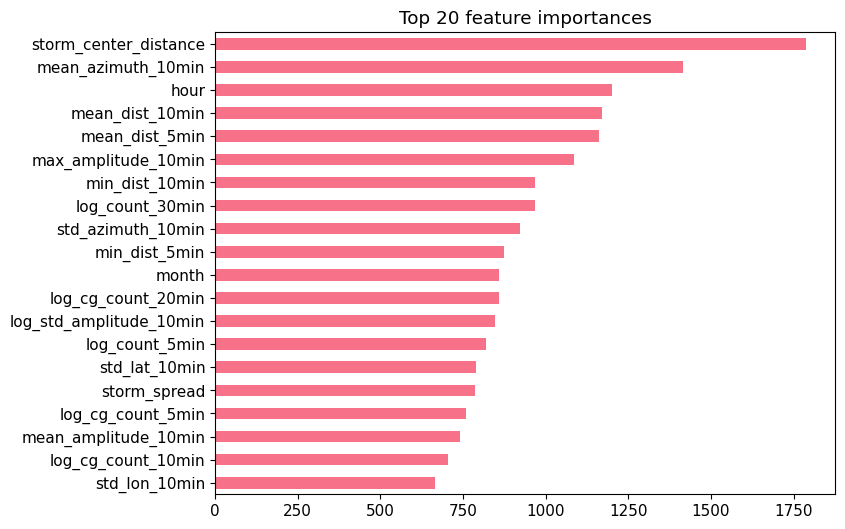

In [79]:
imp.head(20).plot(kind="barh", figsize=(8,6))
plt.gca().invert_yaxis()
plt.title("Top 20 feature importances")
plt.show()

In [80]:
example = val_base.sample(1).iloc[0]

curve = predict_survival_for_row(
    lgb_model,
    example[static_features_main].to_dict(),
    static_features_main,
    horizon=30
)


plt.figure(figsize=(7,4))
plt.plot(curve["minute"], curve["survival"], marker="o")
plt.xlabel("Minutes")
plt.ylabel("Probability of no new CG strike")
plt.title("Predicted survival curve")
plt.grid(True)
plt.show()

[LightGBM] [Fatal] The number of features in data (92) is not the same as it was in training data (91).
You can set ``predict_disable_shape_check=true`` to discard this error, but please be aware what you are doing.


LightGBMError: The number of features in data (92) is not the same as it was in training data (91).
You can set ``predict_disable_shape_check=true`` to discard this error, but please be aware what you are doing.

In [74]:
val_eval_sample = compute_survival_predictions(val_base_sample, lgb_model, static_features_main, HORIZONS)
test_eval_sample = compute_survival_predictions(test_base_sample, lgb_model, static_features_main, HORIZONS)

evaluate_survival_predictions(val_eval_sample, HORIZONS, prefix="Validation sample")
evaluate_survival_predictions(test_eval_sample, HORIZONS, prefix="Test sample")

[LightGBM] [Fatal] The number of features in data (92) is not the same as it was in training data (91).
You can set ``predict_disable_shape_check=true`` to discard this error, but please be aware what you are doing.


LightGBMError: The number of features in data (92) is not the same as it was in training data (91).
You can set ``predict_disable_shape_check=true`` to discard this error, but please be aware what you are doing.

,minute,hazard,survival
0,1,0.047231,0.952769
1,2,0.063257,0.892500
2,3,0.063814,0.835545
3,4,0.064852,0.781358
4,5,0.063303,0.731896
5,6,0.065527,0.683937
6,7,0.066588,0.638395
7,8,0.066767,0.595771
8,9,0.067445,0.555590
9,10,0.068982,0.517264


In [42]:
H = 15
tau = 0.90

p_safe_15 = surv_curve.loc[surv_curve["minute"] == H, "survival"].iloc[0]
decision = int(p_safe_15 > tau)

print("P(no CG strike within 15 min) =", round(p_safe_15, 4))
print("Lift alert?" , decision)

P(no CG strike within 15 min) = 0.3688
Lift alert? 0
